# Retail Product Image Classification

Testing DINOv2 (Meta, 2023) on fashion product sub-category classification. DINOv2 is a self-supervised ViT, backbone frozen, linear classifier trained on top.

**Dataset:** [Fashion Product Images (Small)](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small) — Kaggle

```
data/
  images/
  styles.csv
```

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

torch.manual_seed(42)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
%matplotlib inline

Using device: mps


## Data

In [2]:
data_path = Path('data')
images_path = data_path / 'images'

styles = pd.read_csv(data_path / 'styles.csv', on_bad_lines='skip')
styles['image_path'] = styles['id'].astype(str) + '.jpg'
styles['exists'] = styles['image_path'].apply(lambda x: (images_path / x).exists())
styles = styles[styles['exists']].reset_index(drop=True)

# Classification target — options: masterCategory, subCategory, articleType
target_col = 'subCategory'
styles = styles.dropna(subset=[target_col])

print(f'Total images: {len(styles)}')
print(styles[target_col].value_counts())

Total images: 44419
subCategory
Topwear                     15398
Shoes                        7343
Bags                         3055
Bottomwear                   2693
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Free Gifts                    104
Stoles                         90
Skin Care       

30 classes, 44210 images


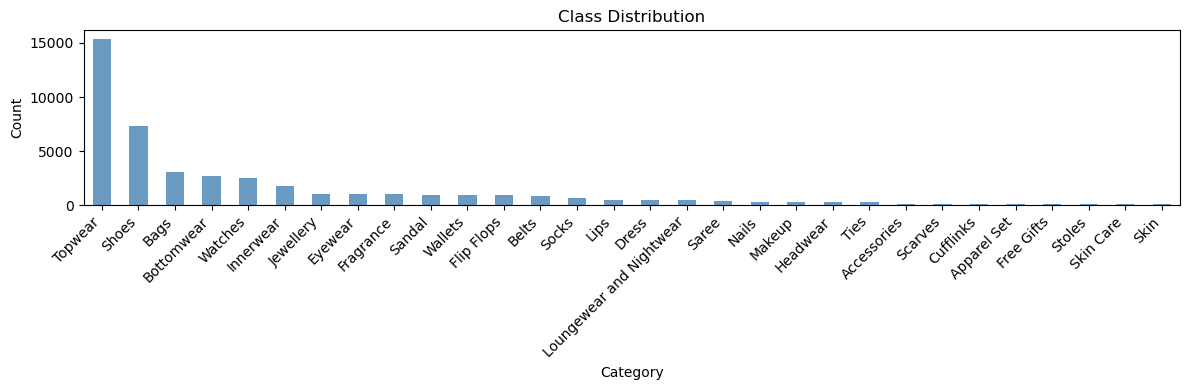

In [3]:
# Keep classes with at least 50 samples
counts = styles[target_col].value_counts()
styles = styles[styles[target_col].isin(counts[counts >= 50].index)].reset_index(drop=True)

print(f'{styles[target_col].nunique()} classes, {len(styles)} images')

plt.figure(figsize=(12, 4))
styles[target_col].value_counts().plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Class Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

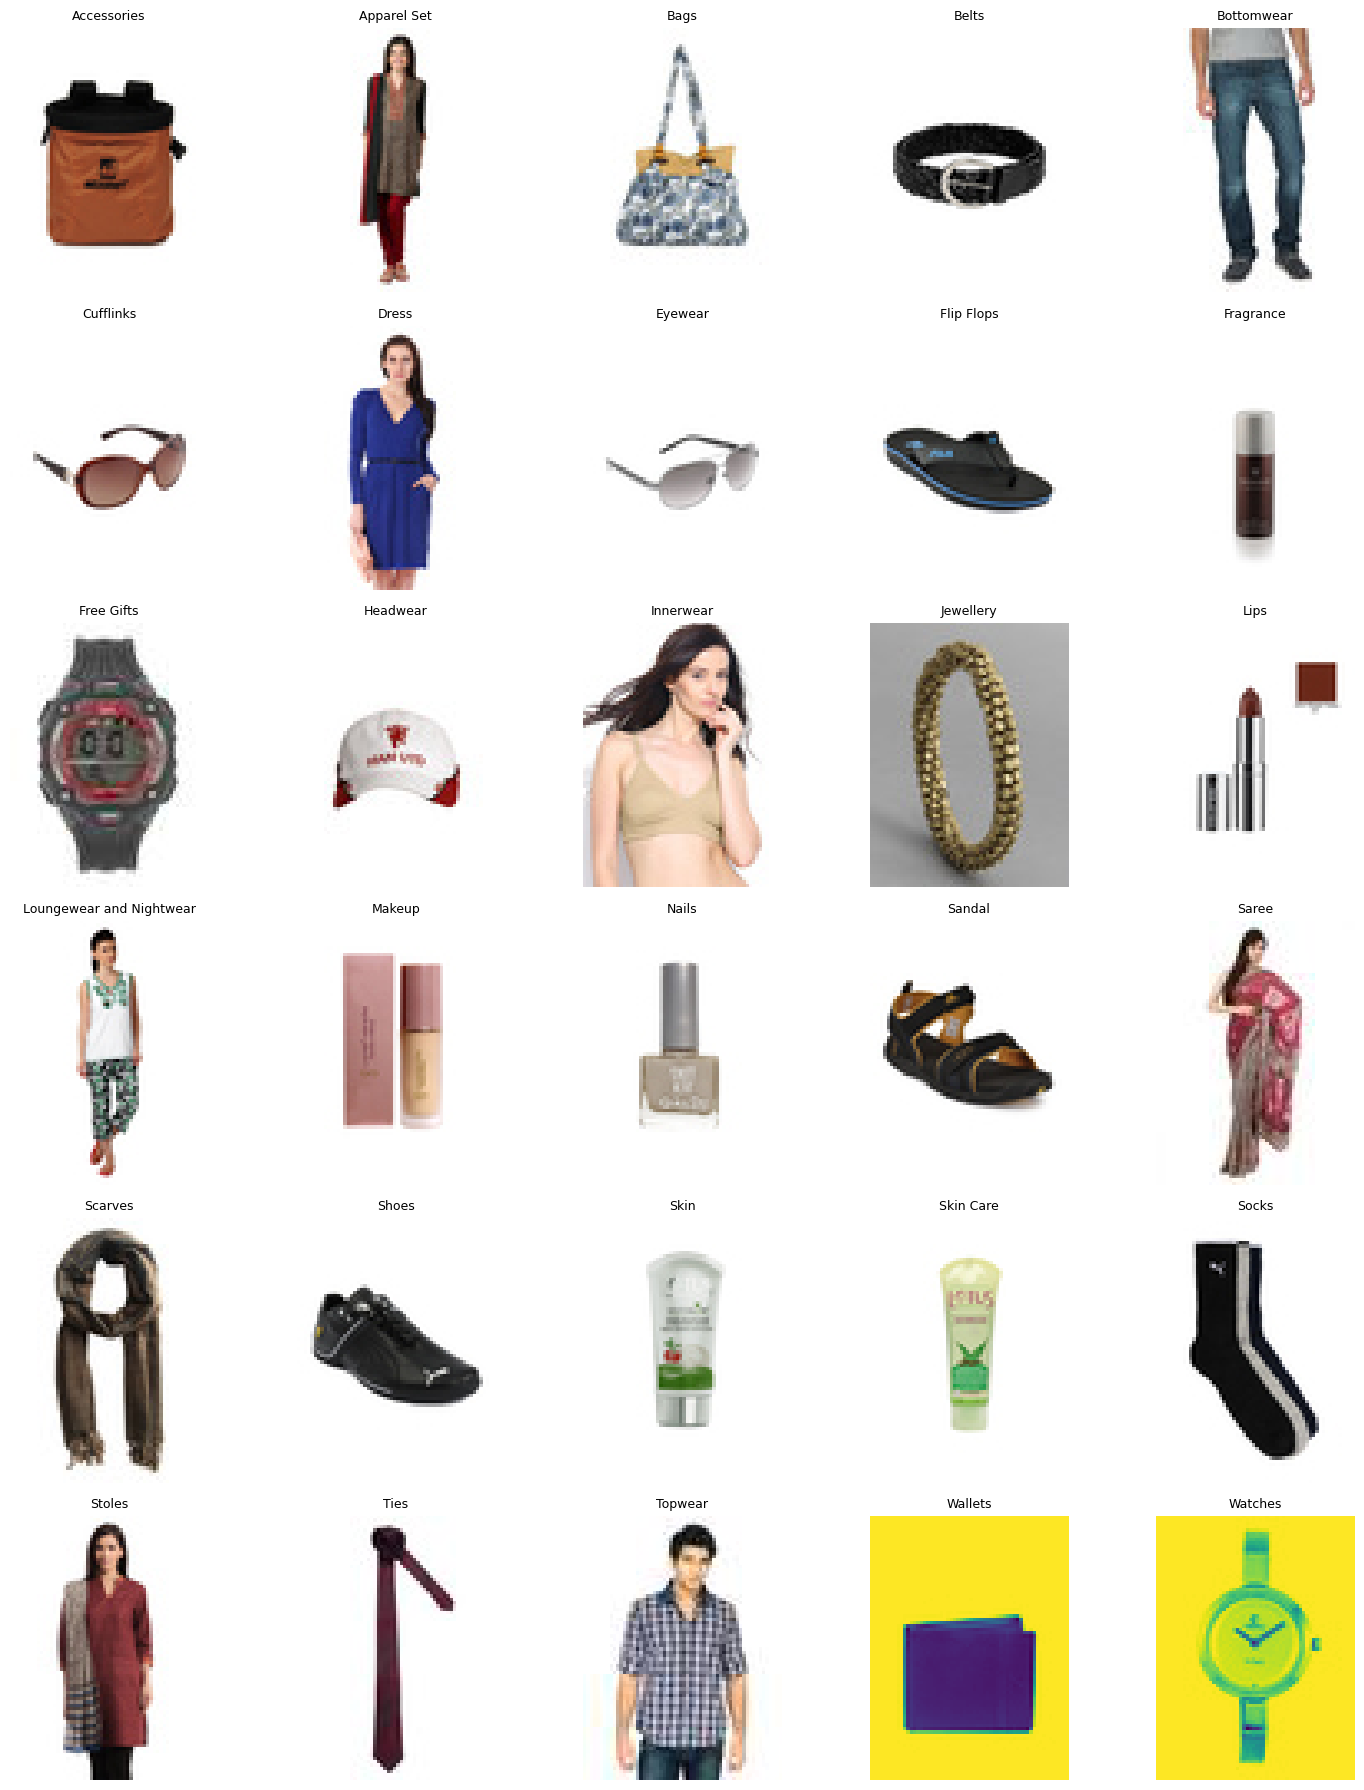

In [4]:
# One sample per class
classes = sorted(styles[target_col].unique())
n_cols  = 5
n_rows  = int(np.ceil(len(classes) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.ravel()

for i, cls in enumerate(classes):
    sample = styles[styles[target_col] == cls].iloc[0]
    img = Image.open(images_path / sample['image_path'])
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Dataset & Transforms

In [5]:
label_encoder = LabelEncoder()
styles['label'] = label_encoder.fit_transform(styles[target_col])
num_classes = len(label_encoder.classes_)

X = styles['image_path'].values
y = styles['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Classes: {list(label_encoder.classes_)}')
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Classes: ['Accessories', 'Apparel Set', 'Bags', 'Belts', 'Bottomwear', 'Cufflinks', 'Dress', 'Eyewear', 'Flip Flops', 'Fragrance', 'Free Gifts', 'Headwear', 'Innerwear', 'Jewellery', 'Lips', 'Loungewear and Nightwear', 'Makeup', 'Nails', 'Sandal', 'Saree', 'Scarves', 'Shoes', 'Skin', 'Skin Care', 'Socks', 'Stoles', 'Ties', 'Topwear', 'Wallets', 'Watches']
Train: 30947 | Val: 6631 | Test: 6632


In [6]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


class ProductDataset(Dataset):
    def __init__(self, image_paths, labels, img_dir, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.img_dir     = img_dir
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_dir / self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


batch_size = 32

train_loader = DataLoader(ProductDataset(X_train, y_train, images_path, train_transform), batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(ProductDataset(X_val,   y_val,   images_path, val_transform),   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(ProductDataset(X_test,  y_test,  images_path, val_transform),   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

## Model

DINOv2 (ViT-S/14) from HuggingFace. Backbone frozen, linear head trained on top.

In [7]:
backbone = AutoModel.from_pretrained('facebook/dinov2-small')

for param in backbone.parameters():
    param.requires_grad = False

backbone = backbone.to(device)
embed_dim = backbone.config.hidden_size


class DINOv2Classifier(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes):
        super().__init__()
        self.backbone   = backbone
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        cls_token = self.backbone(x).last_hidden_state[:, 0]
        return self.classifier(cls_token)


model = DINOv2Classifier(backbone, embed_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} parameters')

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable: 12,318 / 22,068,894 parameters


## Training

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, 100 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, 100 * correct / total

In [9]:
num_epochs       = 10
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc     = 0.0
best_model_state = None

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    for k, v in zip(['train_loss', 'val_loss', 'train_acc', 'val_acc'],
                    [train_loss, val_loss, train_acc, val_acc]):
        history[k].append(v)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch+1:>2}/{num_epochs}  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')

print(f'\nBest val accuracy: {best_val_acc:.2f}%')
model.load_state_dict(best_model_state)

/opt/homebrew/Caskroom/miniforge/base/envs/csenv/lib/python3.11/site-packages/torch/nn/functional.py:4594: UserWarning: The operator 'aten::upsample_bicubic2d.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_951ooclnw1/croot/libtorch_1746637517770/work/aten/src/ATen/mps/MPSFallback.mm:13.)
  return torch._C._nn.upsample_bicubic2d(


Epoch  1/10  Train Loss: 0.3780  Train Acc: 90.24%  Val Loss: 0.2044  Val Acc: 94.24%
Epoch  2/10  Train Loss: 0.2343  Train Acc: 93.75%  Val Loss: 0.2542  Val Acc: 94.16%
Epoch  3/10  Train Loss: 0.2238  Train Acc: 94.43%  Val Loss: 0.2435  Val Acc: 94.53%
Epoch  4/10  Train Loss: 0.1927  Train Acc: 95.09%  Val Loss: 0.2487  Val Acc: 93.91%
Epoch  5/10  Train Loss: 0.1651  Train Acc: 95.52%  Val Loss: 0.2048  Val Acc: 94.98%
Epoch  6/10  Train Loss: 0.1455  Train Acc: 95.82%  Val Loss: 0.2013  Val Acc: 95.08%
Epoch  7/10  Train Loss: 0.1247  Train Acc: 96.37%  Val Loss: 0.1947  Val Acc: 95.22%
Epoch  8/10  Train Loss: 0.1124  Train Acc: 96.57%  Val Loss: 0.1907  Val Acc: 95.19%
Epoch  9/10  Train Loss: 0.1044  Train Acc: 96.81%  Val Loss: 0.1858  Val Acc: 95.52%
Epoch 10/10  Train Loss: 0.0993  Train Acc: 97.02%  Val Loss: 0.1822  Val Acc: 95.58%

Best val accuracy: 95.58%


<All keys matched successfully>

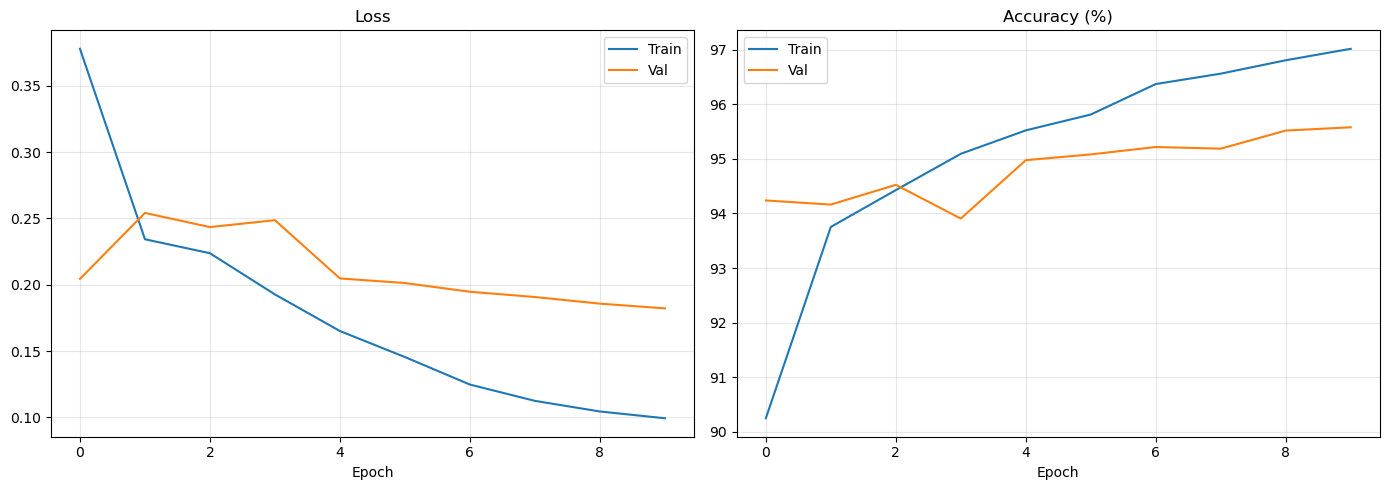

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Test Accuracy: {accuracy_score(all_labels, all_preds) * 100:.2f}%\n')
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

Test Accuracy: 95.70%

                          precision    recall  f1-score   support

             Accessories       0.67      0.95      0.78        19
             Apparel Set       0.81      0.81      0.81        16
                    Bags       0.97      0.97      0.97       459
                   Belts       0.99      0.98      0.99       122
              Bottomwear       0.94      0.96      0.95       404
               Cufflinks       1.00      0.81      0.90        16
                   Dress       0.71      0.79      0.75        72
                 Eyewear       0.99      1.00      1.00       161
              Flip Flops       0.78      0.86      0.82       137
               Fragrance       0.99      0.95      0.97       152
              Free Gifts       0.20      0.13      0.16        15
                Headwear       0.98      0.98      0.98        44
               Innerwear       0.97      0.93      0.95       271
               Jewellery       0.96      0.99      0

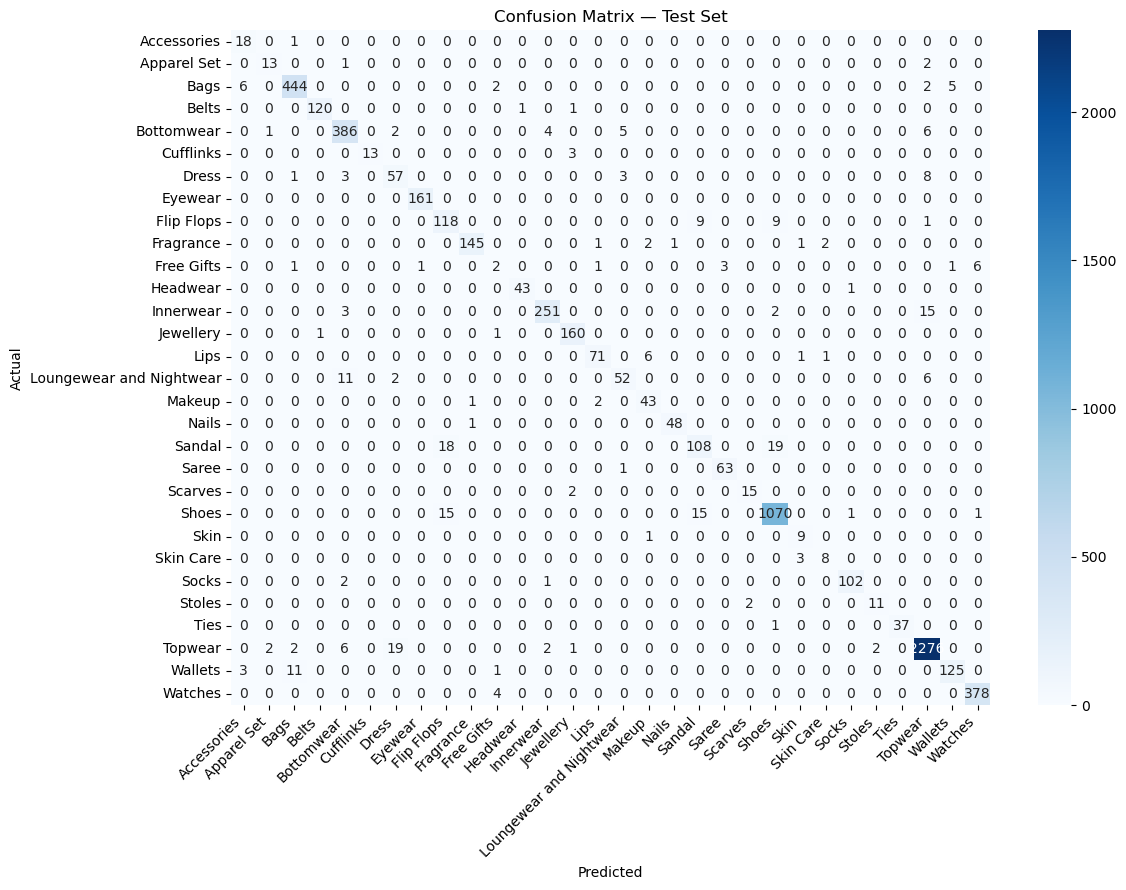

In [12]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

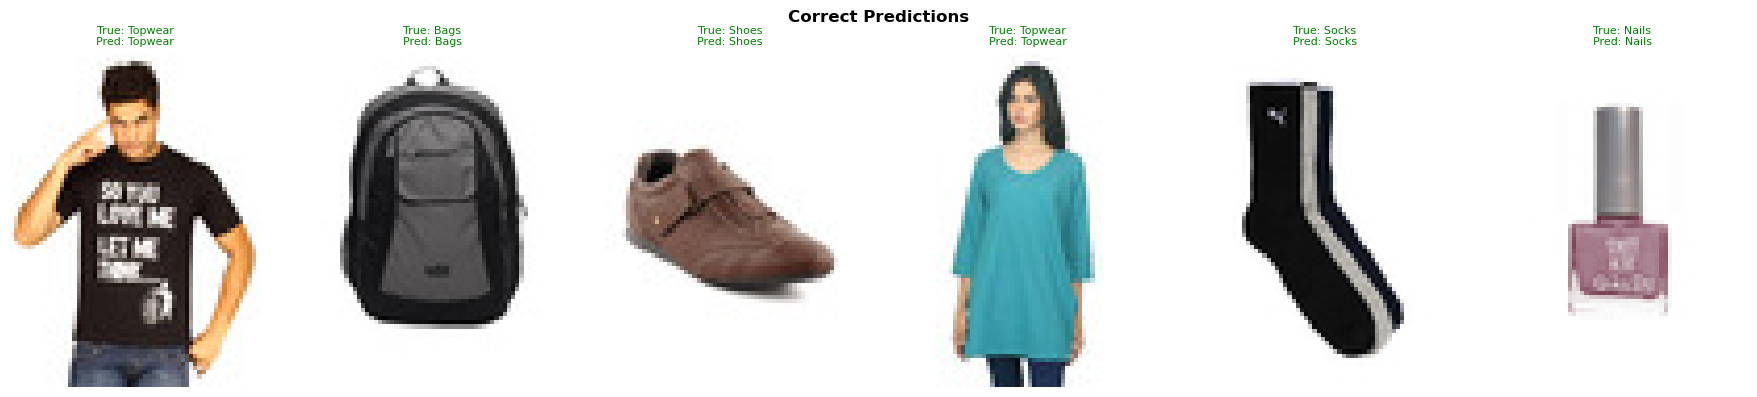

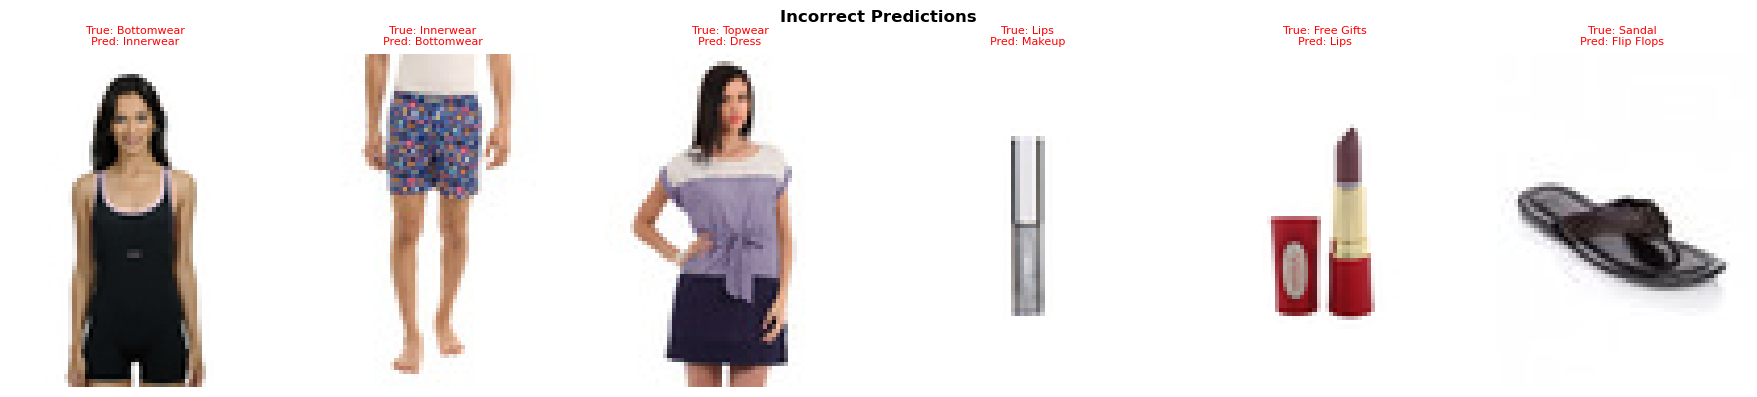

In [13]:
correct_idx   = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

test_dataset = ProductDataset(X_test, y_test, images_path, transform=None)

def show_samples(indices, title_color, title, n=6):
    indices = indices[:n]
    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        img, _ = test_dataset[idx]
        ax.imshow(img)
        ax.set_title(
            f'True: {label_encoder.classes_[all_labels[idx]]}\n'
            f'Pred: {label_encoder.classes_[all_preds[idx]]}',
            color=title_color, fontsize=8
        )
        ax.axis('off')
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(correct_idx) > 0:
    show_samples(correct_idx, 'green', 'Correct Predictions')

if len(incorrect_idx) > 0:
    show_samples(incorrect_idx, 'red', 'Incorrect Predictions')

## Save

In [14]:
torch.save({
    'model_state_dict': model.state_dict(),
    'label_classes':    label_encoder.classes_,
    'num_classes':      num_classes
}, 'dinov2_products.pth')

print('Saved.')

Saved.
